In [1]:
import numpy as np, matplotlib.pyplot as plt, seaborn as sns

mu = 170
sigma = 5
count = 100000

s = np.random.normal(mu, sigma, count)
s_mean = np.mean(s)
cnt = 0

down_g = []
up_g = []
g = []

Я создал массив чисел и посчитал среднее для него

Теперь я создам 100 выборок из 30 и посчиатаю для них доверительные интервалы и посмотрю в скольки из них войдет истинное значение, предпологаю что около 95

In [2]:
for _ in range(100):
    choice = np.random.choice(s, size=30, replace=True)
    p = np.mean(choice)
    SE = np.std(choice, ddof=1) / 30**0.5
    down_g.append(p - 1.96 * SE)
    up_g.append(p + 1.96 * SE)
    if p - 1.96 * SE <= s_mean <= p + 1.96 * SE:
        g.append(True)
        cnt += 1
    else:
        g.append(False)

print(cnt / 100)

0.91


Как я и предпологал 91 случай из 100

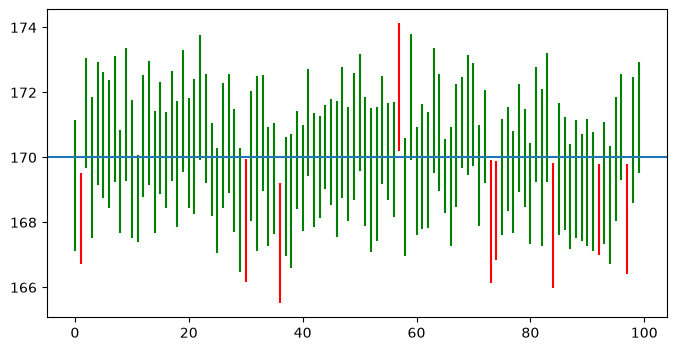

In [3]:
fig, ax = plt.subplots(figsize=(8, 4))
for i in range(100):
    if g[i]:
        ax.vlines(x=i, ymin=down_g[i], ymax=up_g[i], colors='green')
    else:
        ax.vlines(x=i, ymin=down_g[i], ymax=up_g[i], colors='red')
ax.axhline(y=s_mean)
plt.show()

In [4]:
len(down_g), len(up_g), len(g)

(100, 100, 100)

Для тех кто старше 64

In [5]:
p = 1/11
n = 11
SE = (p * (1 - p) / n)**0.5
print(p - 2 * SE, p + 2 * SE)
print((p + 2 * SE) - (p - 2 * SE))

-0.08244774349919859 0.2642659253173804
0.346713668816579


Из 11 людей 1 выживший и 10 погибших, доверительный интервал широкий, левая часть ушла за минус

Для 2 класс из Квинстауна

In [6]:
p = 2/3
n = 3
SE = (p * (1 - p) / n)**0.5
print(p - 2 * SE, p + 2 * SE)
print((p + 2 * SE) - (p - 2 * SE))

0.12233561271484927 1.2109977206184839
1.0886621079036347


Из 3 людей выжило 2, доверительный интервал широкий, ширина больше 1

Для мужчин 3 класса

In [7]:
p = 47/347
n = 347
SE = (p * (1 - p) / n)**0.5
print(p - 2 * SE, p + 2 * SE)
print((p + 2 * SE) - (p - 2 * SE))

0.09870616240305403 0.17218720935487103
0.073481046951817


Из 347 людей выжило 47, доверительный интервал не широкий